In [0]:
# ============================================================
# DIAGRAMA ER – DEFINIÇÃO MERMAID
# ============================================================

mermaid_diagram = """
erDiagram

    dim_tempo {
        date data_dt PK
        int ano
        int mes
        int dia
        string dia_semana
    }

    dim_clube {
        int clube_id PK
        string clube
    }

    dim_arena {
        int arena_id PK
        string arena
    }

    fato_partida {
        int partida_id PK
        date data_dt FK
        int mandante_id FK
        int visitante_id FK
        int arena_id FK
        int mandante_placar
        int visitante_placar
        string vencedor
        int rodada
    }

    fato_gol {
        int partida_id FK
        int clube_id FK
        int minuto_int
        string tipo_de_gol
        int rodada
    }

    fato_cartao {
        int partida_id FK
        int clube_id FK
        string atleta
        string posicao
        string cartao
        int num_camisa
        int minuto_int
        int rodada
    }

    fato_estatistica_time_partida {
        int partida_id FK
        int clube_id FK
        int chutes
        int chutes_no_alvo
        int passes
        float posse_de_bola_num
        float precisao_passes_num
        int faltas
        int cartao_amarelo
        int cartao_vermelho
        int impedimentos
        int escanteios
        int rodada
    }

    dim_tempo ||--o{ fato_partida : data
    dim_clube ||--o{ fato_partida : mandante
    dim_clube ||--o{ fato_partida : visitante
    dim_arena ||--o{ fato_partida : arena

    fato_partida ||--o{ fato_gol : gera
    dim_clube ||--o{ fato_gol : marca

    fato_partida ||--o{ fato_cartao : possui
    dim_clube ||--o{ fato_cartao : recebe

    fato_partida ||--o{ fato_estatistica_time_partida : possui
    dim_clube ||--o{ fato_estatistica_time_partida : participa
"""


In [0]:
# ===============================
# GERAÇÃO DO PNG 
# ===============================

import base64
import requests

# Codifica o Mermaid
encoded = base64.b64encode(mermaid_diagram.encode("utf-8")).decode("utf-8")

# Endpoint Mermaid PNG
url = f"https://mermaid.ink/img/{encoded}"

# Download da imagem
response = requests.get(url)
response.raise_for_status()

# Caminho 
png_path = "/tmp/diagrama_er.png"

with open(png_path, "wb") as f:
    f.write(response.content)

png_path


'/tmp/diagrama_er.png'

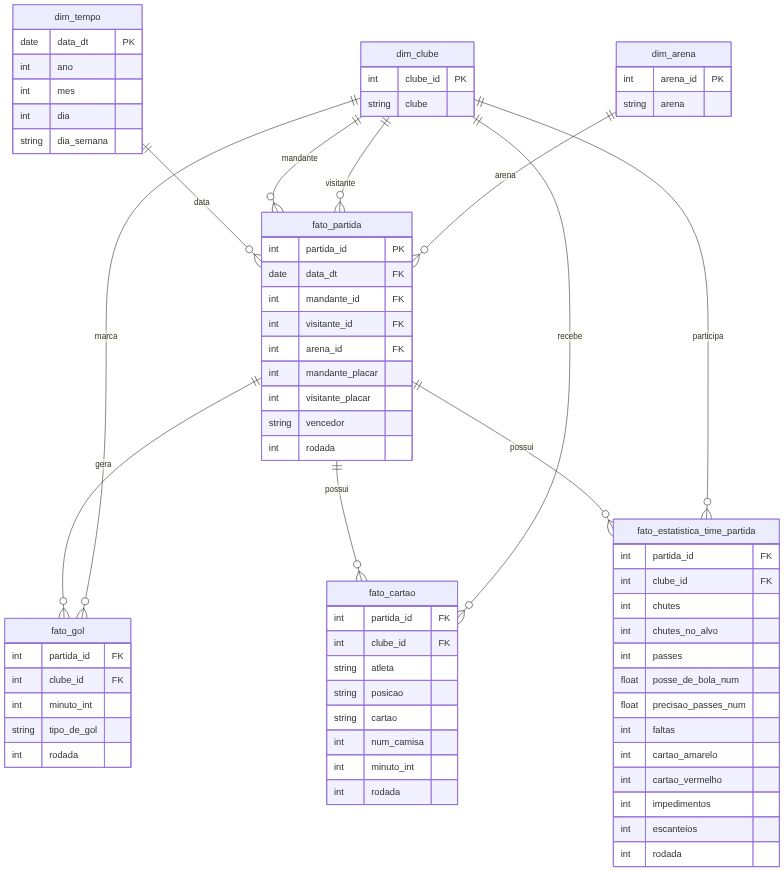

In [0]:
from IPython.display import Image, display

display(Image(filename="/tmp/diagrama_er.png"))
